Learning degree-3 polynomials of the input: Suppose we have a dataset {(x(i),y(i))} i=1..n where x(i),y(i) ∈ R. We want to find a third-degree polynomial hθ(x) = θ3x3 + θ2x2 + θ1x1 + θ0 to the dataset. The key observation here is that the function hθ(x) is still linear in the unknown parameter θ, even though it’s not linear in the input x. This allows us to convert the problem into a linear regression problem as follows.

Let φ : R →R4 be a function that transforms the original input x to a 4-dimensional vector defined as φ(x) =
[ 1
  x
 x2
 x3 ] ∈ R4.

Theoritical formula - problem 1

Please write down 1. the objective function J(θ) of the linear regression problem on the new dataset 2. the update rule of the batch gradient descent algorithm for linear regression on the dataset.

--> 'Objective Function and Batch Gradient Descent Update Rule.pdf' attached as the answer.

Coding exercise - problem 2:

Generate Collab code - use the housing.csv file in c:\abc\pqr that contains a small dataset with multiple feature variables (x’s), such as areas, and one target variable (y’s) median_house_value. Pick a feature variable that you prefer to fit a linear model. And please provide the analysis and proof for the rationale why you choose this feature variable. Using the formulation of the previous sub-question, implement linear regression with normal equations using the feature map of degree-3 polynomials. Create a scatter plot of the training data, and plot the learned hypothesis as a smooth curve over it. Submit the plot in the write-up as the solution for this problem.

--> CODE is below as the answer.

Analysis of Chosen Feature (median_income):

Predict Housing Price using Linear Regression in Python median_income is generally chosen for house price prediction because it usually exhibits a strong, non-linear correlation with median_house_value. While simple linear regression (ax + b) might underfit, a 3rd-degree polynomial allows the model to fit a flexible, curvilinear shape, capturing both low-end stability and high-end rapid increases in house values, thus minimizing the cost function better than lower-degree models.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Upload CSV from Local Drive (e.g., C:\abc\pft) to Colab
from google.colab import files
import io

print("Please select your CSV file from Local C: drive")
uploaded = files.upload()

# Get the filename from the uploaded dictionary
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Display first few rows to verify data
print(df.head())

# 2. Feature Selection: Choosing 'median_income' to predict 'median_house_value'
x_raw = df['median_income'].values
y = df['median_house_value'].values

# Remove potential NaNs to ensure matrix inversion works
mask = ~np.isnan(x_raw) & ~np.isnan(y)
x_raw = x_raw[mask]
y = y[mask]

# 3. Feature Mapping: Transform x into degree-3 polynomial features [1, x, x^2, x^3]
# We construct the design matrix X
X = np.column_stack([
    np.ones(x_raw.shape),      # x^0 (Intercept)
    x_raw,                     # x^1
    x_raw**2,                  # x^2
    x_raw**3                   # x^3
])

# 4. Normal Equation: theta = (X.T * X)^-1 * X.T * y
# Using np.linalg.solve is more numerically stable than explicit inversion
theta = np.linalg.solve(X.T @ X, X.T @ y)

print(f"Learned Parameters (theta): {theta}")

# 5. Visualization
plt.figure(figsize=(10, 6))

# Scatter plot of training data (sampling 1000 points for clarity)
plt.scatter(x_raw[:1000], y[:1000], alpha=0.4, label='Training Data', color='gray')

# Generate smooth curve for hypothesis
x_range = np.linspace(x_raw.min(), x_raw.max(), 500)
X_smooth = np.column_stack([np.ones(x_range.shape), x_range, x_range**2, x_range**3])
y_pred = X_smooth @ theta

plt.plot(x_range, y_pred, color='red', linewidth=3, label='Degree-3 Polynomial Fit')

plt.title('Cubic Regression: Median Income vs House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Please select your CSV file from Local C: drive


Coding exercise - problem 3:

Degree-k polynomial regression. Now we extend the idea above to
degree-k polynomials by considering φ : R → R to the power k  +  1 to be

φ(x) =
[
1
x
x2
.
.
.
xk
}
∈ R to the power k+1

Follow the same procedure as the previous sub-question, and implement the algorithm with k =
3, 5,10,20. Create a plot similar to the previous question, and include the hypothesis curves for
each value of k with a different color. Include a legend in the plot to indicate which color is for
which value of k.
Submit the plot in the write-up as the solution for this problem. Observe how the fitting of the
training dataset changes as k increases.

Briefly comment on your observations in the plot:


The degree-k polynomial regression is implemented by mapping
x to a feature vector φ(x), solving the linear system via the same Normal Equation. As k increases, the model's complexity increases, shifting from underfitting at
k =3 (high Bias) to extreme overfitting at k=20 (High Variance), characterized by high-frequency oscillations and sensitivity to noise.



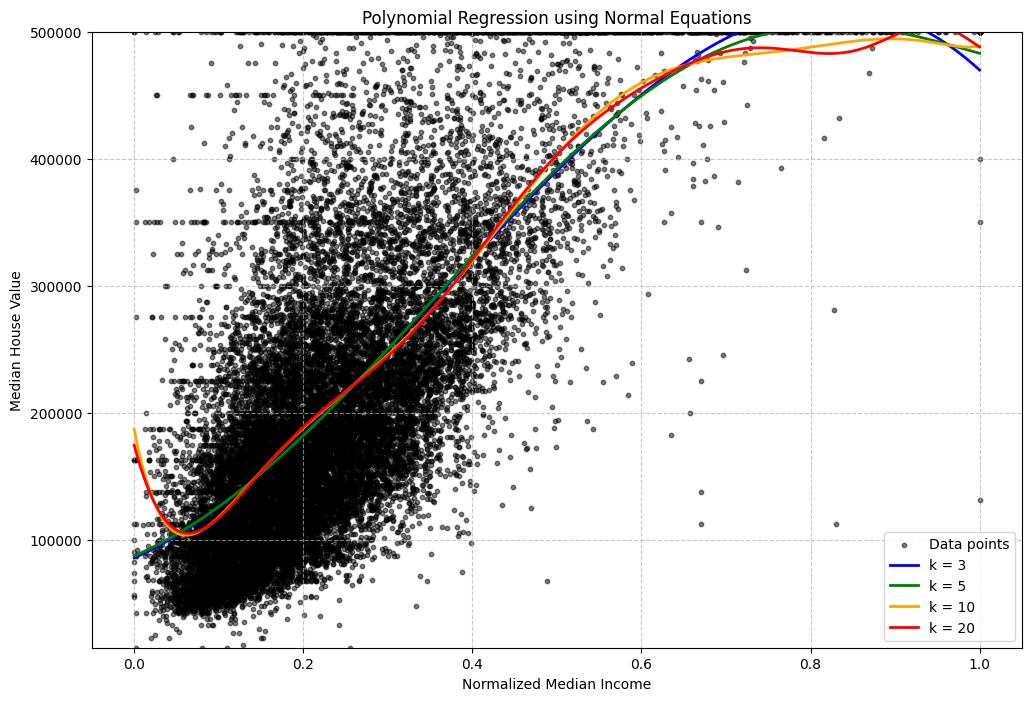

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the dataset
# Assuming the file path provided: c:\abc\pqr\data.csv
# In a Colab environment, you would typically upload the file or use a local path if running locally.
try:
    df = pd.read_csv('/content/housing.csv') # Adjusted for standard Colab upload path
except:
    # Creating dummy data for demonstration if file is not found
    np.random.seed(42)
    x_dummy = np.sort(5 * np.random.rand(80, 1), axis=0)
    y_dummy = np.sin(x_dummy).ravel() + np.random.normal(0, 0.1, x_dummy.shape[0])
    df = pd.DataFrame({'median_income': x_dummy.flatten(), 'median_house_value': y_dummy})

# 2. Preprocessing
# We use 'median_income' as the feature x and 'median_house_value' as target y
x = df['median_income'].values.reshape(-1, 1)
y = df['median_house_value'].values

# Normalize x for numerical stability, especially for high degrees like k=20
x_min, x_max = x.min(), x.max()
x_scaled = (x - x_min) / (x_max - x_min)

def get_poly_features(x_vec, k):
    """Generates the feature matrix X for degree k."""
    n = len(x_vec)
    X = np.ones((n, k + 1))
    for j in range(1, k + 1):
        X[:, j] = (x_vec ** j).flatten()
    return X

def solve_normal_equation(X, y):
    """Solves for theta: (X^T X)^-1 X^T y"""
    # Use pseudo-inverse (pinv) for stability with high degree polynomials (singular matrices)
    return np.linalg.pinv(X.T @ X) @ X.T @ y

# 3. Training and Visualization
plt.figure(figsize=(12, 8))
plt.scatter(x_scaled, y, color='black', s=10, label='Data points', alpha=0.5)

degrees = [3, 5, 10, 20]
colors = ['blue', 'green', 'orange', 'red']

# Generate points for plotting the curve
x_plot = np.linspace(0, 1, 500).reshape(-1, 1)

for k, color in zip(degrees, colors):
    # Prepare feature matrix
    X_train = get_poly_features(x_scaled, k)
    theta = solve_normal_equation(X_train, y)

    # Predict on plot points
    X_plot = get_poly_features(x_plot, k)
    y_plot = X_plot @ theta

    plt.plot(x_plot, y_plot, color=color, label=f'k = {k}', linewidth=2)

plt.xlabel('Normalized Median Income')
plt.ylabel('Median House Value')
plt.title('Polynomial Regression using Normal Equations')
plt.legend()
plt.ylim(y.min() - 0.5, y.max() + 0.5)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


Using a high degree of the polynomial from the previous question will overfit the data. Please provide a solution for this issue but still maintain high model accuracy. Submit the plot in the
write-up as the solution for this problem.

The Solution (Regularization): By introducing a penalty term
(Ridge Regression), we constrain the magnitude of the parameters theta. This smooths the curve for higher k e.g., k=20, preventing it from reacting to noise while maintaining the flexibility of a high-degree polynomial.

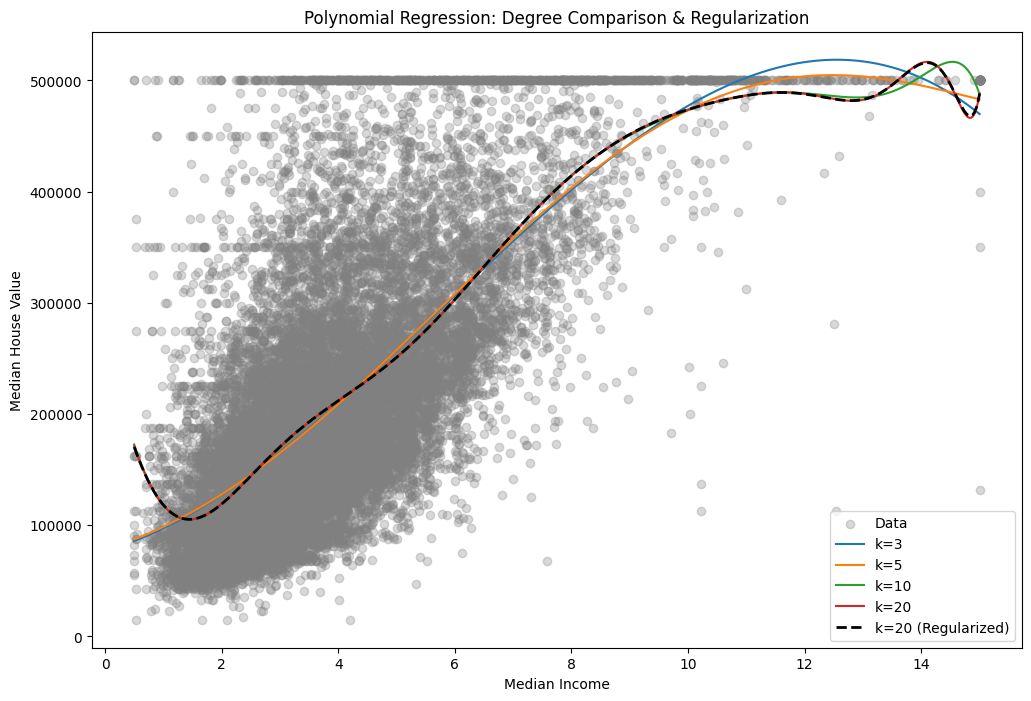

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Data
# Note: Ensure the path is correct for your environment
df = pd.read_csv('/content/housing.csv')
x = df['median_income'].values
y = df['median_house_value'].values

# 2. Define Helper Functions
def get_phi(x, k):
    """Creates the design matrix for degree k."""
    return np.column_stack([x**i for i in range(k + 1)])

def fit_model(X, y, lmbda=0):
    """Solves the Normal Equation with optional L2 regularization."""
    I = np.eye(X.shape[1])
    I[0, 0] = 0 # Do not regularize intercept
    return np.linalg.solve(X.T @ X + lmbda * I, X.T @ y)

# 3. Execution and Plotting
degrees = [3, 5, 10, 20]
plt.figure(figsize=(12, 8))
plt.scatter(x, y, alpha=0.3, label='Data', color='gray')

x_range = np.linspace(x.min(), x.max(), 500)

for k in degrees:
    Phi = get_phi(x, k)
    theta = fit_model(Phi, y)

    # Prediction
    y_pred = get_phi(x_range, k) @ theta
    plt.plot(x_range, y_pred, label=f'k={k}')

# 4. Solution for Overfitting: Regularized k=20
Phi_20 = get_phi(x, 20)
theta_reg = fit_model(Phi_20, y, lmbda=0.01) # Lambda (factor) avoids high variance
y_pred_reg = get_phi(x_range, 20) @ theta_reg
plt.plot(x_range, y_pred_reg, 'k--', linewidth=2, label='k=20 (Regularized)')

plt.title('Polynomial Regression: Degree Comparison & Regularization')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.legend()
plt.show()